# Logistic Regression with Binary Cross Entropy Loss function

Logistic Regression is an algorithm used for classification problems. Unlike linear regression, which predicts continuous values it predicts the probability that an input belongs to a specific class.

## Sigmoid Function

$$ \sigma(z) = \frac{1}{1 + e^{-z}}$$

- As $z \to \infty, \sigma(z) \to 1 $
- As $z \to -\infty, \sigma(z) \to 0 $
- At $ z=0, \sigma(0) = 0.5$ 

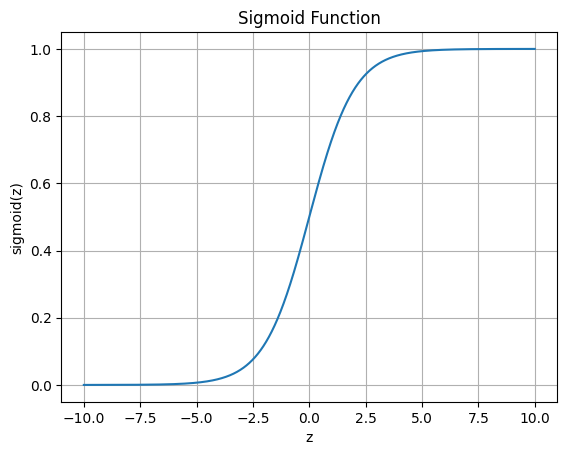

In [1]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-10, 10, 10000)   # 10000 points
y = 1 / (1 + np.exp(-z))          # sigmoid function

plt.plot(z, y)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid()
plt.show()

## Derivative of a Sigmoid function

$$ \sigma(z) = \frac{1}{1 + e^{-z}}$$

$$ \frac{d\sigma}{dz} = \sigma'(z) = \frac{e^{-z}}{(1 + e^{-z})^2}$$

$$ \sigma'(z) = \frac{1}{1 + e^{-z}} \frac{e^{-z}}{1 + e^{-z}}$$

$$ \sigma'(z) = \sigma(z) (1-\sigma(z)) $$

## Practical Problems in using Mean Squared Error (MSE) Loss / Cost function for Classification

### 1. MSE assumes a regression mindset, not classification

MSE is defined as:

$$ MSE = \frac{1}{m} \sum (y - \hat{y})^2$$

- It treats outputs as continuous values.
- But classification is about probabilities / discrete classes (0 or 1).

So MSE doesn’t align well with the goal of classification (predicting correct class probabilities).

### 2. Wrong confidence is not punished enough

Example:

| Prediction | True Label | MSE   |
|:---:       | :---:      | :---: |
| 0.9        | 1          | 0.01  |
| 0.1        | 1          | 0.81  |


| Prediction | True Label | MSE   |
|:---:       | :---:      | :---: |
| 0.1        | 0          | 0.01  |
| 0.9        | 0          | 0.81  |

This does n't look fine.

Now compare with probability-based loss (like cross-entropy):
- Predicting 0.1 when true is 1 should be heavily penalized.
- Predicting 0.9 when true is 0 should be heavily penalized.

MSE penalty is not strong enough for bad confident predictions.

This slows learning and leads to poor classifiers with MSE loss functions.

### 3. Gradient problem

In classification, we usually use:
- Sigmoid (for Binary Classification)
- Softmax (For Multi-Class Classification)

When we combine MSE + Sigmoid, we will get gradients like:

$$ \nabla L \propto (y - \hat{y}) \cdot \sigma'(z)$$

But:
- $\sigma'(z)$ becomes very small when output is near 0 or 1

This causes:
- Vanishing gradients
- Slow or stalled learning

But with Cross Entropy loss function:
$$ \nabla L \propto (y - \hat{y}) $$

Hence, the problem of vanishing gradients does n't exist with Cross Entropy loss function.

### 4. Cross-Entropy fixes this problem

For classification, we use:
- Binary Cross Entropy (BCE)
- Categorical Cross Entropy

Because they are derived from Maximum Likelihood Estimation (MLE).

They:
- Match probabilistic interpretation
- Give strong gradients even for wrong predictions
- Train much faster and more reliably

## Maximum Likelihood Estimation (MLE)

In Maximum Likelihood Estimation, we choose model parameters $w$ that maximize the probability of observed data.

For a dataset:

$$ \left\{ \left(x^{(1)}, y^{(1)}\right), \left(x^{(2)}, y^{(2)}\right), \cdots, \left(x^{(m)}, y^{(m)}\right) \right\} $$

We maximize:

$$ \prod_{i=1}^{m} P\left(y^{(i)} \mid x^{(i)} ; w\right)$$

To make it easier, we take log:

$$ \sum_{i=1}^m \log P\left( y^{(i)} \mid x^{(i)} ; w \right)$$

In ML, we usually minimize loss, so we take negative log-likelihood (NLL):

$$ L(w) = - \sum_{i=1}^m \log P\left( y^{(i)} \mid x^{(i)} ; w \right)$$

Now focus on one data point:

$$ \log P(y \mid x) $$

For multi-class classification:
$$ \hat{y}_k = P(y = k \mid x; w) $$

So:
- $\hat{y}_1, \hat{y}_2, \cdots, \hat{y}_K$ are predicted probabilities
- True label is one class (say class $j$)

Instead of writing:

$$ P(y = j \mid x) $$

We use one-hot vector:
$$ y = (y_1, y_2, \cdots, y_K) $$ 

where:
- $y_j = 1$
- rest are 0

So, we can rewrite the probabilities using one-hot trick:

$$ P(y \mid x) = \prod_{k=1}^K \hat{y}_k^{y_k} $$

Why this works:
- Only the true class has $y_k = 1$
- Others are 0 → disappear

So effectively:
$$ P(y \mid x) = \hat{y}_{\text{true class}} $$

Take log

$$ \log P(y \mid x) = \log \left( \prod_k \hat y_k^{y_k}  \right) $$

$$ \log P(y \mid x) = \sum_k y_k \log(\hat{y}_k)$$

Plugging this into MLE

$$ L(w) = - \sum_{i=1}^m\sum_k y_k^{(i)} \log(\hat{y}_k^{(i)}) $$ 

For a single sample:

$$ L(w) = - \sum_k y_k \log (\hat{y}_k)$$

## Categorical Cross Entropy Loss

$$ \text{Categorical Cross Entropy Loss} = - \sum_k y_k \log(\hat{y}_k)$$

## Binary Cross Entropy Loss

For multi-class (K classes):

$$ \text{Categorical Cross Entropy Loss} = - \sum_{k=1}^K y_k log(\hat{y}_k) $$

In binary classification (K = 2), we only have:
- Class 0
- Class 1

So,
- $y = (y_0, y_1)$
- $y = (\hat{y}_0, \hat{y}_1)$

And:
$$ y_0 + y_1 = 1 $$
$$ \hat{y}_0 + \hat{y}_1 = 1 $$

Plug into Categorical Cross Entropy Loss:

$$ Loss = -[y_0 \log(\hat{y}_0) + y_1 \log(\hat{y}_1)] $$ 

In binary problems, we usually define:
- $y \in \{0, 1\}$
- $\hat{y} = P(y = 1 \mid x)$

So:
$$ y_1 = y $$
$$ y_0 = 1-y $$
$$ \hat{y}_1 = \hat{y} $$
$$ \hat{y}_0 = 1-\hat{y} $$

Substitute

$$ Loss = -\left[(1-y) \log(1-\hat{y}) + y \log(\hat{y})\right] $$ 

$$ \text{Binary Cross Entropy Loss} =  -\left[y \log(\hat{y}) + (1-y) \log(1-\hat{y})\right] $$

Desirable properties of loss function:
- $L = 0$ if $y = \hat{y}$
- $L$ should be very high for misclassification
- $L > 0$

With binary cross entropy loss function:
- If $y \to 0$ and $\hat{y} \to 1$, then, $\text{loss} \to \infty$
- If $y \to 1$ and $\hat{y} \to 0$, then, $\text{loss} \to \infty$ 

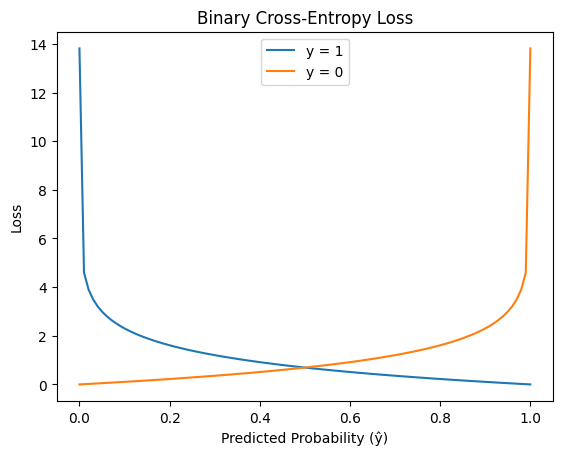

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Predicted probabilities (avoid 0 and 1 to prevent log(0))
y_hat = np.linspace(1e-6, 1 - 1e-6, 100)

# Binary Cross-Entropy loss
loss_y1 = -np.log(y_hat)          # when true label y = 1
loss_y0 = -np.log(1 - y_hat)      # when true label y = 0

# Plot
plt.figure()
plt.plot(y_hat, loss_y1, label='y = 1')
plt.plot(y_hat, loss_y0, label='y = 0')

plt.xlabel('Predicted Probability (ŷ)')
plt.ylabel('Loss')
plt.title('Binary Cross-Entropy Loss')
plt.legend()

plt.show()

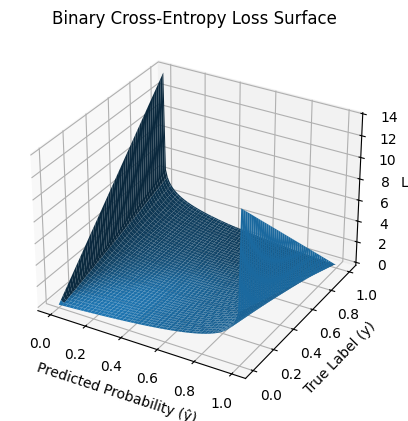

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create range of values
y_hat = np.linspace(1e-6, 1 - 1e-6, 100)   # predicted probability
y = np.linspace(0, 1, 100)                 # true label (continuous for visualization)

# Create meshgrid
Y_hat, Y = np.meshgrid(y_hat, y)

# Binary Cross-Entropy loss
Z = -(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat))

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Y_hat, Y, Z)

# Labels
ax.set_xlabel('Predicted Probability (ŷ)')
ax.set_ylabel('True Label (y)')
ax.set_zlabel('Loss')
ax.set_title('Binary Cross-Entropy Loss Surface')

plt.show()

## Gradient of Logistic Regression

Predicted value:

$$ \hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}} $$

Binary Cross Entropy Loss:

$$ L = \sum_{i=1}^m L^{(i)} $$

$$ L =  - \sum_{i=1}^m\left[y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)}) \log(1-\hat{y}^{(i)})\right] $$

Using chain rule:

$$ \frac{\partial L^{(i)}}{\partial w} = \frac{\partial L^{(i)}}{\partial \hat{y}^{(i)}}
\frac{\partial \hat{y}^{(i)}}{\partial z} \frac{\partial z}{\partial w} $$


$ \frac{\partial L}{\partial \hat{y}}$ :
$$ \frac{\partial L}{\partial \hat{y}} = -\left( \frac{y}{\hat{y}} - \frac{1-y}{1-\hat{y}} \right)$$

$\frac{\partial \hat{y}}{\partial z}$ : 
$$\frac{\partial \hat{y}}{\partial z} = \sigma'(z) = \sigma(z) (1 - \sigma(z)) = \hat{y} (1 - \hat{y})$$

$ \frac{\partial L}{\partial \hat{y}} \frac{\partial \hat{y}}{\partial z}$ :

$$ \frac{\partial L}{\partial \hat{y}} \frac{\partial \hat{y}}{\partial z} = -
\left(\frac{y}{\hat{y}} - \frac{1-y}{1-\hat{y}}\right)
\hat{y}(1 - \hat{y})
$$

$$ \frac{\partial L}{\partial z} = \frac{\partial L}{\partial \hat{y}} \frac{\partial \hat{y}}{\partial z} = -(y - \hat{y})$$


Now for any data point $(x, y)$, 
$$ z = \mathbf{x} \cdot \mathbf{w} = \mathbf{w}^T \mathbf{x} = \mathbf{x}^T \mathbf{w} $$

where:
$$ \mathbf{x} = [x_0, x_1, x_2, \cdots, x_d, \cdots, x_D]^T = [1, x, x^2, \cdots, x^d, \cdots x^D]^T $$ 
$$ \mathbf{w} = [w_0, w_1, w_2, \cdots, w_d, \cdots, w_D]^T$$
$$ D = \text{degree of the polynomial features}$$

Therefore, 

$$ \frac{\partial z}{\partial w_d} = x_d = x^d$$

Hence,

$$ \frac{\partial L}{\partial w_d} = \sum_{i=1}^m(y - \hat{y}) x_d$$

## OR Gate Classifier using Logistic Regression

In [4]:
import numpy as np

# Input (OR gate)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Output
y = np.array([0, 1, 1, 1]).reshape(-1, 1)

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Initialize weights and bias
w = np.zeros((2, 1))
b = 0

# Learning rate
lr = 0.1

# Training
for i in range(10000):
    # z = np.dot(X, w) + b
    z = X @ w + b
    y_pred = sigmoid(z)
    
    # Gradients
    # nabla_w = (1/4) * np.dot(X.T, (y_pred - y))
    nabla_w = (1/4) * (X.T @ (y_pred - y))
    nabla_b = (1/4) * np.sum(y_pred - y)
    
    # Update
    w -= lr * nabla_w
    b -= lr * nabla_b

# Predictions
z = np.dot(X, w) + b
y_pred = sigmoid(z)
predictions = (y_pred >= 0.5).astype(int)

print("Inputs:")
print(X)

print("Predicted outputs:")
print(predictions)

Inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Predicted outputs:
[[0]
 [1]
 [1]
 [1]]


## Multinomial Logistic Regression (Multi-label Classification)

Requirements of Non-linear function:
- $\hat{y}_k \in [0, 1] \forall k$
- $\displaystyle \sum_{k=1}^K{y_k} = 1$

### Softmax function

$$
\operatorname{softmax}(z_i) = \frac{e^{z_i}}{\displaystyle \sum_{k=1}^{K} e^{z_k}} ; i = 1, 2, \cdots, K
$$

$$
\mathbf{\hat{y}} = \operatorname {softmax} (\mathbf{z})
$$

where

$$ 
\mathbf{z} = 
\begin{bmatrix}
z_1 \\
z_2 \\
\vdots \\
z_K
\end{bmatrix}
$$ 